# Деревья принятия решений и Ансамбли

В этом блокноте мы перейдем от линейных моделей к более гибким алгоритмам. Мы разберем, как работают **деревья решений**, почему они склонны к переобучению, и как **ансамбли** (случайный лес, бустинг) помогают сделать модели устойчивее и точнее.

> **Идея:** вместо одной прямой линии мы будем строить систему правил («если возраст > 30, то...»), а затем объединять множество таких правил.

## Постановка задачи

Импортируем некоторые полезные библиотеки:

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Библиотеки для бустинга (могут потребовать установки: pip install xgboost catboost)
try:
    import xgboost as xgb
    import catboost as cb
except ImportError:
    !pip install xgboost catboost
    import xgboost as xgb
    import catboost as cb

sns.set_style("whitegrid")

Сгенерируем синтетический датасет для классификации. Представим, что мы предсказываем, одобрит ли банк кредит, основываясь на двух признаках (например, доход и сумма займа).

- `0` — отказ
- `1` — одобрение

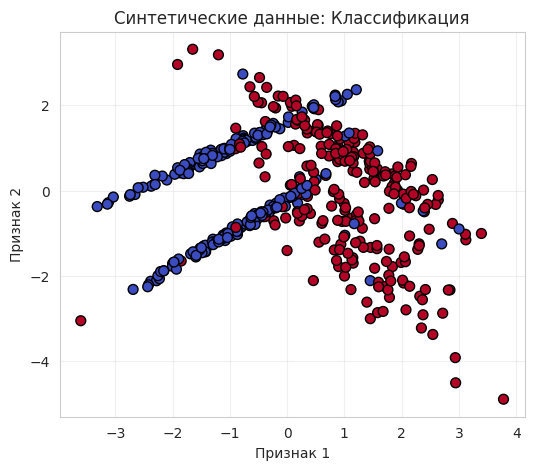

In [25]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=1.0,
    flip_y=0.1,
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='coolwarm', edgecolors='k')
plt.title("Синтетические данные: Классификация")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True, alpha=0.3)
plt.show()

## Decision Tree: Как это работает?

Дерево решений задает последовательность вопросов к данным. Каждый вопрос разбивает данные на две группы.

### Энтропия и Прирост информации

Как дерево понимает, какой вопрос задать первым? Оно пытается сделать группы внутри узлов как можно более «чистыми» (чтобы в одной группе были только класс 0, а в другой — только класс 1).

Для этого используется **Энтропия** (мера хаоса):
$$
H(S) = - \sum_{i} p_i \log_2(p_i)
$$
где $p_i$ — доля объектов класса $i$ в узле.

- Если в узле только объекты одного класса, энтропия = 0 (идеальный порядок).
- Если классы перемешаны 50/50, энтропия = 1 (максимальный хаос).

Дерево выбирает признак, который максимально уменьшает энтропию. Это уменьшение называется **Приростом информации (Information Gain)**.

<details>
<summary><b>Вопрос 1.</b> Почему энтропия максимальна при равном соотношении классов?</summary>

Потому что неопределенность максимальна: мы совершенно не можем предсказать класс нового объекта. Когда же один класс доминирует, неопределенность меньше.
</details>

<details>
<summary><b>Вопрос 2.</b> Что будет, если в узле только один объект?</summary>

Энтропия будет равна 0 (полная определенность), но это признак переобучения — модель запомнила конкретный объект вместо общей закономерности.
</details>

### Реализация: Одно дерево

С помощью LLM сгенерируйте код, который:
1. Обучит `DecisionTreeClassifier` (ограничьте глубину `max_depth=3` для наглядности).
2. Визуализирует решающую границу на плоскости.
3. Визуализирует само дерево с помощью `plot_tree`.

<details>
<summary><b>Подсказка.</b> Как визуализировать границу решения?</summary>

1. Создайте сетку точек через `np.meshgrid`
2. Предскажите класс для каждой точки сетки
3. Используйте `plt.contourf` для отображения областей
</details>

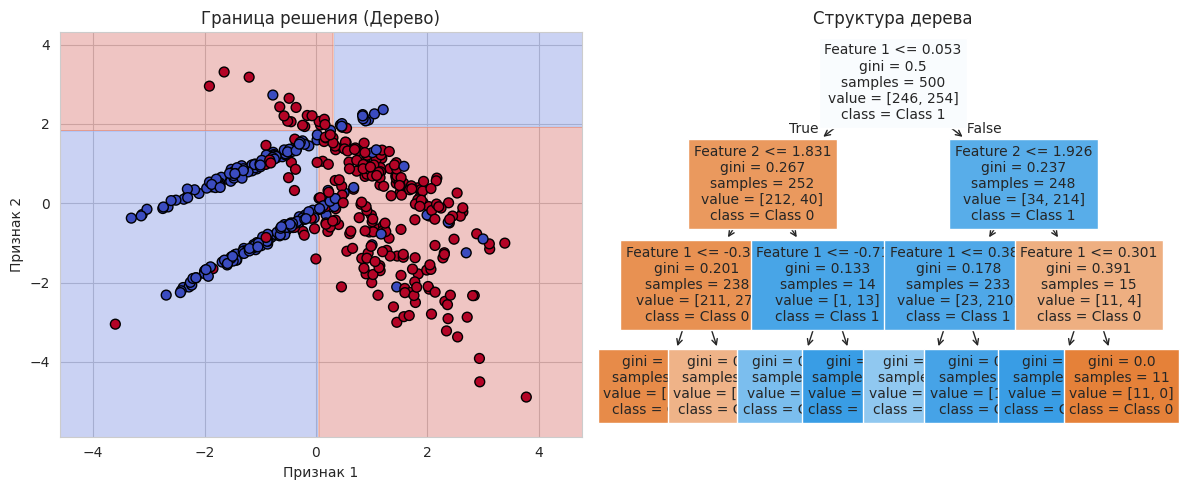

In [26]:
# Обучаем дерево
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X, y)

# Визуализация границы
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = dt_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='k', cmap='coolwarm')
plt.title("Граница решения (Дерево)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")

# Визуализация дерева
plt.subplot(1, 2, 2)
plot_tree(dt_model, feature_names=['Feature 1', 'Feature 2'],
          class_names=['Class 0', 'Class 1'], filled=True, fontsize=10)
plt.title("Структура дерева")

plt.tight_layout()
plt.show()

### Вопросы:

<details>
<summary><b>Вопрос 3.</b> Почему граница решения дерева состоит из прямоугольных областей?</summary>

Потому что каждое разбиение в дереве — это проверка условия вида "признак > порог". На плоскости это создает вертикальные или горизонтальные линии, которые формируют прямоугольники.
</details>

<details>
<summary><b>Вопрос 4.</b> Что означают числа в узлах визуализированного дерева?</summary>

- `samples` — количество объектов в узле
- `value` — распределение по классам [класс_0, класс_1]
- `gini` — мера неоднородности (аналог энтропии)
</details>

<details>
<summary><b>Вопрос 5.</b> Каким свойством обладает корневой узел?</summary>

Корневой узел содержит признак, который лучше всего разделяет данные (максимальный прирост информации).
</details>

### Переобучение деревьев

С помощью LLM сгенерируйте код, который:
1. Разделит данные на train/test (70/30, `random_state=42`).
2. Обучит дерево без сильных ограничений глубины (`max_depth=10000`).
3. Обучит дерево с `max_depth=3`.
4. Выведет accuracy на train и test для обеих моделей.

<details>
<summary><b>Вопрос.</b> Что вы ожидаете увидеть?</summary>

Дерево без ограничений будет иметь accuracy ≈ 1.0 на train, но значительно хуже на test (переобучение). Дерево с ограничением будет иметь более сбалансированные результаты.
</details>

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Дерево без ограничений
dt_over = DecisionTreeClassifier(max_depth=10000, random_state=42)
dt_over.fit(X_train, y_train)

print(f"Accuracy на обучении (без лимита): {accuracy_score(y_train, dt_over.predict(X_train)):.3f}")
print(f"Accuracy на тесте (без лимита):    {accuracy_score(y_test, dt_over.predict(X_test)):.3f}")

# Дерево с ограничением
dt_reg = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_reg.fit(X_train, y_train)

print(f"Accuracy на обучении (max_depth=3): {accuracy_score(y_train, dt_reg.predict(X_train)):.3f}")
print(f"Accuracy на тесте (max_depth=3):    {accuracy_score(y_test, dt_reg.predict(X_test)):.3f}")

Accuracy на обучении (без лимита): 1.000
Accuracy на тесте (без лимита):    0.860
Accuracy на обучении (max_depth=3): 0.897
Accuracy на тесте (max_depth=3):    0.900


### Вопросы:

<details>
<summary><b>Вопрос 6.</b> Почему дерево без ограничений переобучается?</summary>

Оно создает слишком много правил, подстраиваясь под шум в обучающих данных. Каждому объекту может соответствовать свой лист дерева.
</details>

<details>
<summary><b>Вопрос 7.</b> Какие еще есть идеи для регуляризации дерева? Какие параметры дерева можно ограничить?</summary>

- `min_samples_split` — минимальное число объектов для разбиения узла
- `min_samples_leaf` — минимальное число объектов в листе
- `max_features` — максимальное число признаков для рассмотрения
- `max_leaf_nodes` — максимальное число листьев
</details>

## Ансамбли: Сила в количестве

Одно дерево нестабильно: немного изменим данные — получим совсем другое дерево. Решение — использовать **ансамбль** моделей.

### 1. Бэггинг (Bagging) и Случайный лес

Мы обучаем много деревьев на разных подвыборках данных (с возвращением) и усредняем их ответы (голосование).

- **Случайный лес (Random Forest)**: дополнительно выбирает случайные признаки для каждого split. Это уменьшает корреляцию между деревьями.

### 2. Бустинг (Boosting)

Деревья обучаются последовательно. Каждое следующее дерево пытается исправить ошибки предыдущего.

- **Gradient Boosting**: минимизирует функцию потерь градиентным спуском.
- **XGBoost**: оптимизированная версия (быстрее, регуляризация).
- **CatBoost**: хорошо работает с категориальными признаками (без предварительного кодирования).

### Сравнение моделей

С помощью LLM сгенерируйте код, который обучит и сравнит:
1. `DecisionTreeClassifier`
2. `RandomForestClassifier` (n_estimators=50)
3. `GradientBoostingClassifier` (n_estimators=50)

Выведите `accuracy` для каждой модели на тесте.

<details>
<summary><b>Вопрос.</b> Какую модель вы ожидаете увидеть лучшей?</summary>

Обычно Gradient Boosting показывает лучшее качество, но требует больше времени на обучение. Random Forest более устойчив к переобучению.
</details>

In [28]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: Accuracy = {acc:.3f}")

Decision Tree: Accuracy = 0.860
Random Forest: Accuracy = 0.887
Gradient Boosting: Accuracy = 0.900


### Детали:

- Ансамбли обычно лучше одной модели. Они уменьшают дисперсию (variance) предсказаний. Разные модели ошибаются по-разному, и при усреднении ошибки компенсируются.

- В методах, основанных на деревьях, например в Random Forest, полезно использовать out-of-bag (OOB) ошибку. Это ошибка на объектах, которые не попали в bootstrap-выборку для данного дерева. Можно использовать для оценки качества без отдельной тестовой выборки.

## Продвинутый бустинг: XGBoost и CatBoost

Эти библиотеки являются индустриальным стандартом для табличных данных. Они часто выигрывали соревнования по машинному обучению.

Попробуем обучить XGBoost и CatBoost на тех же данных.

In [29]:
try:
    # XGBoost
    xgb_model = xgb.XGBClassifier(n_estimators=50, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    print(f"XGBoost: Accuracy = {accuracy_score(y_test, xgb_model.predict(X_test)):.3f}")

    # CatBoost (обычно требует указания cat_features, но работает и без них на числах)
    cb_model = cb.CatBoostClassifier(iterations=50, random_state=42, verbose=0)
    cb_model.fit(X_train, y_train)
    print(f"CatBoost: Accuracy = {accuracy_score(y_test, cb_model.predict(X_test)):.3f}")
except Exception as e:
    print(f"Ошибка при запуске бустинга (проверьте установку библиотек): {e}")

XGBoost: Accuracy = 0.907
CatBoost: Accuracy = 0.887


### Детали:

Чем XGBoost лучше обычного GradientBoosting?

- Регуляризация (L1, L2)
- Работа с пропусками
- Параллелизация
- Более эффективная работа с памятью

В чем преимущество CatBoost?

- Автоматическая работа с категориальными признаками
- Меньше переобучения на маленьких датасетах
- Ordered boosting для борьбы с target leakage

## Работа с реальными данными: Telco Customer Churn

Теперь перейдем к реальным данным. Мы будем использовать [датасет](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) **Telco Customer Churn** от IBM/Kaggle.

**Задача:** Предсказать, уйдет ли клиент от оператора связи (churn).

- `0` — клиент остался
- `1` — клиент ушел

In [30]:
import kagglehub
import pandas as pd

# Загрузка данных с kaggle
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
telco_data = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Размер датасета: {telco_data.shape}")
print(f"\nИнформация о датасете:")
print(telco_data.info())
print(f"\nРаспределение целевой переменной:")
print(telco_data['Churn'].value_counts())
telco_data

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Размер датасета: (7043, 21)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  Streaming

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Подготовка данных
С помощью LLM сгенерируйте код, который:
1. Разделит признаки на числовые и категориальные.
2. Обработает категориальные признаки (One-Hot Encoding или Label Encoding).
3. Разделит данные на train/test (80/20, `stratify=y`, `random_state=42`).

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ============================================================
# Шаг 1: Разделение признаков на числовые и категориальные
# ============================================================

# Удаляем customerID (не является признаком) и Churn (целевая переменная)
X = telco_data.drop(['customerID', 'Churn'], axis=1)
y = telco_data['Churn']

# Преобразуем TotalCharges из object в numeric (там могут быть пустые строки)
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')

# Заполним пропуски в TotalCharges медианой (если есть)
X['TotalCharges'].fillna(X['TotalCharges'].median(), inplace=True)

# Преобразуем целевую переменную в числовой формат (Yes/No → 1/0)
y = y.map({'Yes': 1, 'No': 0})

# Определяем числовые и категориальные признаки
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")
print(f"Целевая переменная: Churn (0 = остался, 1 = ушел)")

# ============================================================
# Шаг 2: Обработка категориальных признаков (One-Hot Encoding)
# ============================================================

# Создаём препроцессор для раздельной обработки числовых и категориальных признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),           # Масштабирование числовых
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)  # One-Hot для категорий
    ],
    remainder='drop'  # Остальные столбцы удаляем
)

# ============================================================
# Шаг 3: Разделение на train/test (80/20, stratify=y)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% на тест
    random_state=42,         # Фиксация случайности
    stratify=y               # Сохранение пропорции классов
)

print(f"\n{'='*60}")
print("Результаты разделения данных:")
print(f"{'='*60}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# Проверка баланса классов
print(f"\nДоля оттока в train: {y_train.mean():.2%}")
print(f"Доля оттока в test: {y_test.mean():.2%}")

# ============================================================
# Шаг 4: Применение преобразований к данным
# ============================================================

# Обучаем препроцессор на train и применяем к train и test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Получаем имена признаков после One-Hot Encoding
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

print(f"\n{'='*60}")
print("После предобработки:")
print(f"{'='*60}")
print(f"Количество признаков до: {X.shape[1]}")
print(f"Количество признаков после: {X_train_processed.shape[1]}")
print(f"Имена признаков: {all_feature_names[:10]}... (всего {len(all_feature_names)})")

Числовые признаки (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Категориальные признаки (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Целевая переменная: Churn (0 = остался, 1 = ушел)

Результаты разделения данных:
X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)

Доля оттока в train: 26.54%
Доля оттока в test: 26.54%

После предобработки:
Количество признаков до: 19
Количество признаков после: 30
Имена признаков: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes']... (всего 30)


/tmp/ipykernel_402/1070428148.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['TotalCharges'].fillna(X['TotalCharges'].median(), inplace=True)


### Обучение моделей на реальных данных

С помощью LLM сгенерируйте код, который:
1. Обучит одиночное дерево DecisionTreeClassifier на подготовленных данных.
2. Обучит Random Forest.
3. Обучит XGBoost и CatBoost.
4. Выведет classification report и confusion matrix для всех моделей.
5. Посчитает ROC-AUC для всех моделей.

DECISION TREE vs RANDOM FOREST vs CatBoost vs XGBoost

СРАВНЕНИЕ МЕТРИК

--- Decision Tree ---

              precision    recall  f1-score   support

    Stay (0)       0.84      0.88      0.86      1035
   Churn (1)       0.63      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


--- Random Forest ---

              precision    recall  f1-score   support

    Stay (0)       0.84      0.91      0.87      1035
   Churn (1)       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


--- CatBoost ---

              precision    recall  f1-score   support

    Stay (0)       0.84      0.90      0.87      1035
   Churn (1)       0.65      0.52      0.58       374

    accuracy                           0.80

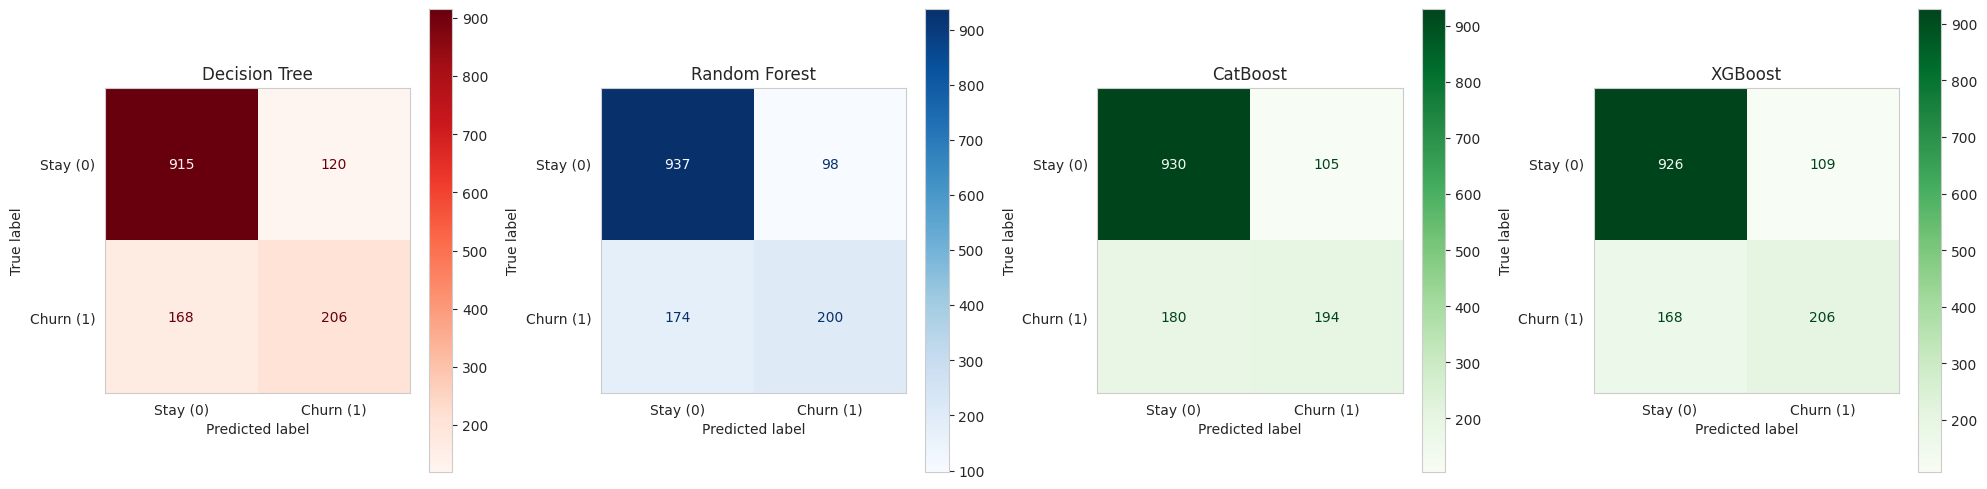


ROC-AUC СРАВНЕНИЕ
Decision Tree ROC-AUC:  0.8287
Random Forest ROC-AUC:  0.8427
CatBoost ROC-AUC:    0.8443
XGBoost ROC-AUC:    0.8389


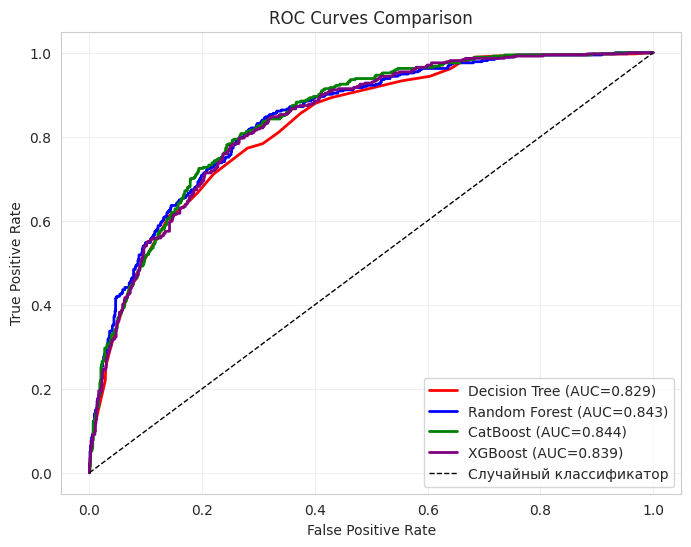


ИТОГОВАЯ СВОДКА
       Модель ROC-AUC Accuracy (Train) Accuracy (Test)
Decision Tree  0.8287           0.8005          0.7956
Random Forest  0.8427           0.8647          0.8070
     CatBoost  0.8443           0.8367          0.7977
      XGBoost  0.8389           0.8681          0.8034

🏆 Лучшая модель по ROC-AUC: CatBoost


In [32]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================================
# Шаг 1: Обучение Decision Tree
# ============================================================

dt_model = DecisionTreeClassifier(
    max_depth=5,           # Ограничиваем глубину для наглядности
    random_state=42,
    min_samples_split=20,  # Регуляризация
    min_samples_leaf=10
)

dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)
y_proba_dt = dt_model.predict_proba(X_test_processed)[:, 1]

print("=" * 60)
print("DECISION TREE vs RANDOM FOREST vs CatBoost vs XGBoost")
print("=" * 60)

# ============================================================
# Шаг 2: Обучение Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]


# ============================================================
# Шаг 3: Обучение XGBoost / CatBoost / GradientBoosting
# ============================================================

models_trained = {}
models_info = {}

# Пробуем CatBoost первым
try:
    import catboost as cb

    cat_model = cb.CatBoostClassifier(
        iterations=100,
        depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=0,
        loss_function='Logloss'
    )

    cat_model.fit(X_train_processed, y_train)
    y_pred_cat = cat_model.predict(X_test_processed)
    y_proba_cat = cat_model.predict_proba(X_test_processed)[:, 1]

    models_trained['CatBoost'] = cat_model
    models_info['CatBoost'] = {'pred': y_pred_cat, 'proba': y_proba_cat}

except ImportError:
    print("⚠️ CatBoost не установлен")

# Пробуем XGBoost
try:
    import xgboost as xgb

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )

    xgb_model.fit(X_train_processed, y_train)
    y_pred_xgb = xgb_model.predict(X_test_processed)
    y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

    models_trained['XGBoost'] = xgb_model
    models_info['XGBoost'] = {'pred': y_pred_xgb, 'proba': y_proba_xgb}

except ImportError:
    print("⚠️ XGBoost не установлен")

# ============================================================
# Шаг 4: Classification Report для всех моделей
# ============================================================

print("\n" + "=" * 60)
print("СРАВНЕНИЕ МЕТРИК")
print("=" * 60)

# Decision Tree
print("\n--- Decision Tree ---\n")
print(classification_report(y_test, y_pred_dt, target_names=['Stay (0)', 'Churn (1)']))

# Random Forest
print("\n--- Random Forest ---\n")
print(classification_report(y_test, y_pred_rf, target_names=['Stay (0)', 'Churn (1)']))

# Остальные модели
for name, info in models_info.items():
    print(f"\n--- {name} ---\n")
    print(classification_report(y_test, info['pred'], target_names=['Stay (0)', 'Churn (1)']))

# ============================================================
# Шаг 5: Confusion Matrix для всех моделей
# ============================================================

n_models = 2 + len(models_info)  # DT + RF + бустинги
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

if n_models == 1:
    axes = [axes]

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Stay (0)', 'Churn (1)'])
disp_dt.plot(ax=axes[0], cmap='Reds', values_format='d')
axes[0].set_title(f'Decision Tree')
axes[0].grid(False)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Stay (0)', 'Churn (1)'])
disp_rf.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'Random Forest')
axes[1].grid(False)

# Остальные модели
for idx, (name, info) in enumerate(models_info.items(), start=2):
    cm = confusion_matrix(y_test, info['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(ax=axes[idx], cmap='Greens', values_format='d')
    axes[idx].set_title(f'{name}')
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

# ============================================================
# Шаг 6: ROC-AUC для всех моделей
# ============================================================

from sklearn.metrics import roc_curve

print("\n" + "=" * 60)
print("ROC-AUC СРАВНЕНИЕ")
print("=" * 60)

roc_results = {}
roc_results['Decision Tree'] = roc_auc_score(y_test, y_proba_dt)
print(f"Decision Tree ROC-AUC:  {roc_results['Decision Tree']:.4f}")

roc_results['Random Forest'] = roc_auc_score(y_test, y_proba_rf)
print(f"Random Forest ROC-AUC:  {roc_results['Random Forest']:.4f}")

for name, info in models_info.items():
    roc_results[name] = roc_auc_score(y_test, info['proba'])
    print(f"{name} ROC-AUC:    {roc_results[name]:.4f}")

# Визуализация ROC-кривых
plt.figure(figsize=(8, 6))

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, linewidth=2, color='red',
         label=f'Decision Tree (AUC={roc_results["Decision Tree"]:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, linewidth=2, color='blue',
         label=f'Random Forest (AUC={roc_results["Random Forest"]:.3f})')

# Остальные модели
colors = ['green', 'purple', 'orange']
for idx, (name, info) in enumerate(models_info.items()):
    fpr, tpr, _ = roc_curve(y_test, info['proba'])
    plt.plot(fpr, tpr, linewidth=2, color=colors[idx % len(colors)],
             label=f'{name} (AUC={roc_results[name]:.3f})')

# Диагональ (случайный классификатор)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# Шаг 7: Итоговая сводка
# ============================================================

print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)

results = {
    'Модель': ['Decision Tree', 'Random Forest'] + list(models_info.keys()),
    'ROC-AUC': [f'{roc_results["Decision Tree"]:.4f}',
                f'{roc_results["Random Forest"]:.4f}'] +
               [f'{roc_results[name]:.4f}' for name in models_info.keys()],
    'Accuracy (Train)': [f'{dt_model.score(X_train_processed, y_train):.4f}',
                         f'{rf_model.score(X_train_processed, y_train):.4f}'] +
                        [f'{models_trained[name].score(X_train_processed, y_train):.4f}'
                         for name in models_info.keys()],
    'Accuracy (Test)': [f'{dt_model.score(X_test_processed, y_test):.4f}',
                        f'{rf_model.score(X_test_processed, y_test):.4f}'] +
                       [f'{models_trained[name].score(X_test_processed, y_test):.4f}'
                        for name in models_info.keys()]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Определяем лучшую модель
best_model = max(roc_results, key=roc_results.get)
print(f"\n🏆 Лучшая модель по ROC-AUC: {best_model}")

<details>
<summary><b>Вопрос 8.</b> Какая модель показала наилучший результат?</summary>

Потому что классы могут быть несбалансированы, и ROC-AUC оценивает качество ранжирования, а не просто правильность предсказаний.
</details>

<details>
<summary><b>Вопрос 9.</b> Почему ROC-AUC лучше accuracy для этой задачи?</summary>

Потому что классы могут быть несбалансированы, и ROC-AUC оценивает качество ранжирования, а не просто правильность предсказаний.
</details>

<details>
<summary><b>Вопрос 10.</b> Что важнее в задаче churn prediction: precision или recall?</summary>

Зависит от бизнес-задачи. Если удержание клиента дорогое — важнее precision (не тратить бюджет на тех, кто не уйдет). Если потеря клиента очень дорогая — важнее recall (не пропустить тех, кто уйдет).
</details>

## Важность признаков и Визуализация

Одно из преимуществ деревьев — возможность понять, какие признаки важны для предсказания.

С помощью LLM сгенерируйте код, который:
1. Извлечет feature importances из Random Forest.
2. Построит bar plot топ-10 важных признаков.
3. Подпишет оси и добавит заголовок.

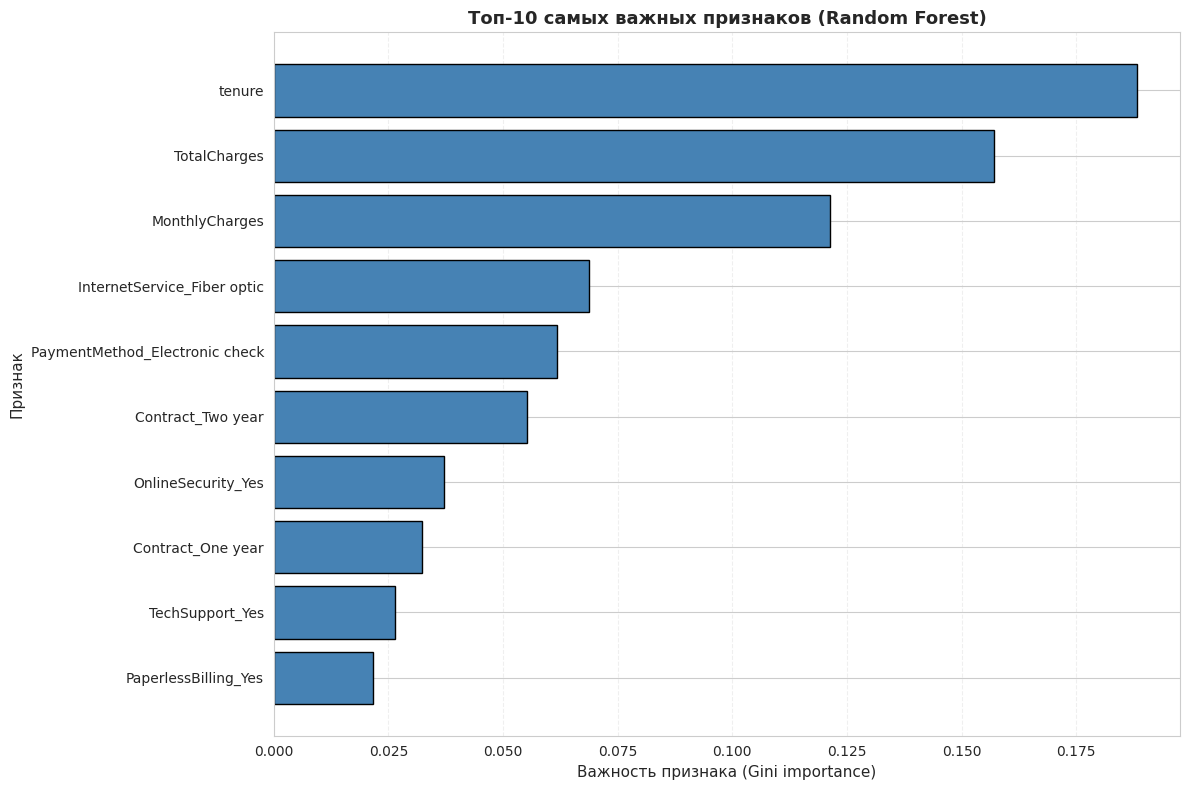

Топ-10 важных признаков для предсказания оттока клиентов:

№   Признак                               Важность
--------------------------------------------------
1   tenure                                  0.1882
2   TotalCharges                            0.1571
3   MonthlyCharges                          0.1214
4   InternetService_Fiber optic             0.0687
5   PaymentMethod_Electronic check          0.0617
6   Contract_Two year                       0.0553
7   OnlineSecurity_Yes                      0.0370
8   Contract_One year                       0.0323
9   TechSupport_Yes                         0.0263
10  PaperlessBilling_Yes                    0.0217

Доля важности топ-10 признаков: 76.97%


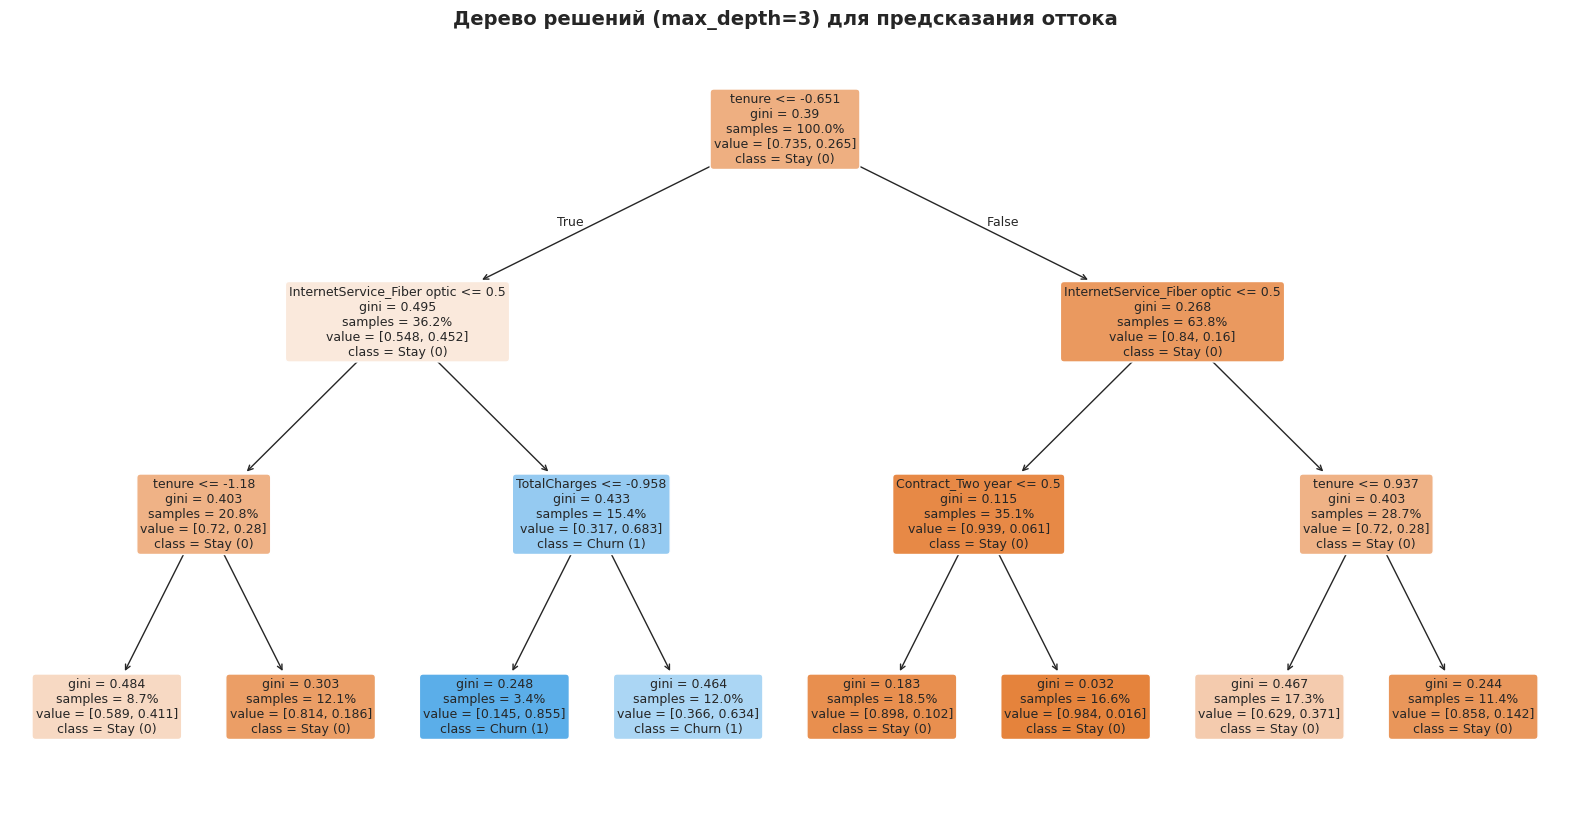


ПРИМЕРЫ ПРАВИЛ ИЗ ДЕРЕВА

Правила классификации:
      → ЛИСТ: tenure <= -0.65 И InternetService_Fiber optic <= 0.50 И tenure <= -1.18 И → Класс: 0 (вероятность: 58.94%)
      → ЛИСТ: tenure <= -0.65 И InternetService_Fiber optic <= 0.50 И tenure > -1.18 И → Класс: 0 (вероятность: 81.38%)
      → ЛИСТ: tenure <= -0.65 И InternetService_Fiber optic > 0.50 И TotalCharges <= -0.96 И → Класс: 1 (вероятность: 85.49%)
      → ЛИСТ: tenure <= -0.65 И InternetService_Fiber optic > 0.50 И TotalCharges > -0.96 И → Класс: 1 (вероятность: 63.41%)
      → ЛИСТ: tenure > -0.65 И InternetService_Fiber optic <= 0.50 И Contract_Two year <= 0.50 И → Класс: 0 (вероятность: 89.81%)
      → ЛИСТ: tenure > -0.65 И InternetService_Fiber optic <= 0.50 И Contract_Two year > 0.50 И → Класс: 0 (вероятность: 98.40%)
      → ЛИСТ: tenure > -0.65 И InternetService_Fiber optic > 0.50 И tenure <= 0.94 И → Класс: 0 (вероятность: 62.94%)
      → ЛИСТ: tenure > -0.65 И InternetService_Fiber optic > 0.50 И tenure > 0.94

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ============================================================
# Шаг 1: Извлечение важности признаков из Random Forest
# ============================================================

# Получаем важности признаков из обученной модели
importances = rf_model.feature_importances_

# ============================================================
# Шаг 2: Получение имён признаков после предобработки
# ============================================================

# Имена числовых признаков остаются без изменений
feature_names = numeric_features.copy()

# Получаем имена признаков после One-Hot Encoding для категориальных
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Объединяем все имена признаков
all_feature_names = feature_names + list(cat_feature_names)

# ============================================================
# Шаг 3: Создание DataFrame для удобной работы
# ============================================================

# Создаём DataFrame с признаками и их важностями
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

# Сортируем по убыванию важности
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# ============================================================
# Шаг 4: Визуализация топ-10 важных признаков
# ============================================================

# Выбираем топ-10 признаков
top_10 = feature_importance_df.head(10)

# Строим горизонтальный bar plot
plt.figure(figsize=(12, 8))
plt.barh(range(10), top_10['importance'].values[::-1], color='steelblue', edgecolor='black')
plt.yticks(range(10), top_10['feature'].values[::-1], fontsize=10)
plt.xlabel('Важность признака (Gini importance)', fontsize=11)
plt.ylabel('Признак', fontsize=11)
plt.title('Топ-10 самых важных признаков (Random Forest)', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ============================================================
# Шаг 5: Вывод числовых значений для анализа
# ============================================================

print("Топ-10 важных признаков для предсказания оттока клиентов:\n")
print(f"{'№':<3} {'Признак':<35} {'Важность':>10}")
print("-" * 50)
for idx, row in enumerate(top_10.itertuples(index=False), 1):
    print(f"{idx:<3} {row.feature:<35} {row.importance:>10.4f}")

# Суммарная важность топ-10 признаков
top_10_share = top_10['importance'].sum()
print(f"\nДоля важности топ-10 признаков: {top_10_share:.2%}")

# ============================================================
# Шаг 6: Визуализация небольшого дерева решений
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Обучаем отдельное дерево с небольшой глубиной для наглядности
dt_viz = DecisionTreeClassifier(
    max_depth=3,           # Ограничиваем глубину для читаемости
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10
)

dt_viz.fit(X_train_processed, y_train)

# Визуализируем дерево (ИСПРАВЛЕННАЯ ВЕРСИЯ)
plt.figure(figsize=(20, 10))
plot_tree(
    dt_viz,
    feature_names=all_feature_names,
    class_names=['Stay (0)', 'Churn (1)'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=True,        # Было 'gini', теперь True/False
    proportion=True       # Показывать пропорции вместо количества
)
plt.title('Дерево решений (max_depth=3) для предсказания оттока', fontsize=14, fontweight='bold')
plt.show()

# ============================================================
# Шаг 7: Интерпретация правил дерева
# ============================================================

print("\n" + "=" * 60)
print("ПРИМЕРЫ ПРАВИЛ ИЗ ДЕРЕВА")
print("=" * 60)

# Получаем пути до листьев для интерпретации
from sklearn.tree import _tree

tree_ = dt_viz.tree_
feature_names_arr = np.array(all_feature_names)

def print_tree_rules(tree, feature_names, node=0, depth=0, rule=""):
    if tree.children_left[node] == _tree.TREE_LEAF:
        # Листовой узел
        value = tree.value[node][0]
        total = value.sum()
        if total > 0:
            class_pred = np.argmax(value)
            prob = value[class_pred] / total
            print(f"{'  ' * depth}→ ЛИСТ: {rule} → Класс: {class_pred} (вероятность: {prob:.2%})")
    else:
        # Внутренний узел
        feature = feature_names[tree.feature[node]]
        threshold = tree.threshold[node]

        # Левая ветвь (<=)
        new_rule_left = f"{rule} {feature} <= {threshold:.2f} И" if rule else f"{feature} <= {threshold:.2f} И"
        print_tree_rules(tree, feature_names, tree.children_left[node], depth + 1, new_rule_left)

        # Правая ветвь (>)
        new_rule_right = f"{rule} {feature} > {threshold:.2f} И" if rule else f"{feature} > {threshold:.2f} И"
        print_tree_rules(tree, feature_names, tree.children_right[node], depth + 1, new_rule_right)

print("\nПравила классификации:")
print_tree_rules(tree_, feature_names_arr)

## Демонстрация устойчивости ансамблей

С помощью LLM сгенерируйте код, который:
1. Обучит 10 Decision Trees на разных random_state.
2. Обучит 10 Random Forest на разных random_state.
3. Посчитает стандартное отклонение accuracy для обоих подходов.

<details>
<summary><b>Вопрос.</b> Что вы ожидаете увидеть?</summary>

Random Forest будет иметь значительно меньшее стандартное отклонение — это демонстрирует его устойчивость к изменению данных.
</details>

ДЕМОНСТРАЦИЯ УСТОЙЧИВОСТИ АНСАМБЛЕЙ

Количество итераций: 10
Размер тестовой выборки: 1409 объектов

Итерация 1: DT = 0.7353, RF = 0.8027
Итерация 2: DT = 0.7410, RF = 0.8048
Итерация 3: DT = 0.7360, RF = 0.8041
Итерация 4: DT = 0.7346, RF = 0.8027
Итерация 5: DT = 0.7367, RF = 0.8020
Итерация 6: DT = 0.7402, RF = 0.8041
Итерация 7: DT = 0.7353, RF = 0.8055
Итерация 8: DT = 0.7346, RF = 0.8020
Итерация 9: DT = 0.7360, RF = 0.8034
Итерация 10: DT = 0.7395, RF = 0.8027

СТАТИСТИКИ УСТОЙЧИВОСТИ

Decision Tree:
  Mean Accuracy: 0.7369
  Std Accuracy:  0.0023
  Min Accuracy:  0.7346
  Max Accuracy:  0.7410

Random Forest:
  Mean Accuracy: 0.8034
  Std Accuracy:  0.0011
  Min Accuracy:  0.8020
  Max Accuracy:  0.8055

📊 Разница в стандартном отклонении: 0.0011
   Random Forest в 2.0 раз стабильнее!


/tmp/ipykernel_402/3003596552.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=labels, patch_artist=True,


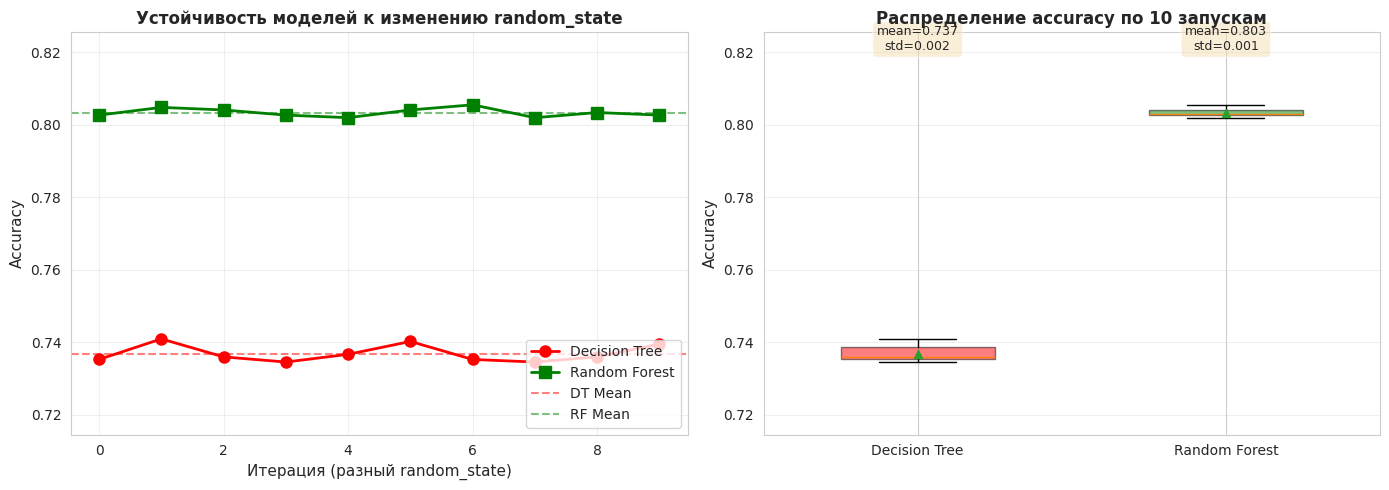


ВЫВОДЫ
✅ Random Forest показал МЕНЬШЕЕ стандартное отклонение
   → Ансамбль более устойчив к изменению данных
   → Предсказания более стабильны и надёжны

💡 Практическое значение:
   - Decision Tree: разброс accuracy = ±0.0023
   - Random Forest: разброс accuracy = ±0.0011
   - В продакшене мы хотим минимальный разброс → выбираем ансамбль!


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ============================================================
# Шаг 1: Обучение 10 Decision Trees на разных random_state
# ============================================================

n_iterations = 10
dt_accuracies = []
rf_accuracies = []

print("=" * 60)
print("ДЕМОНСТРАЦИЯ УСТОЙЧИВОСТИ АНСАМБЛЕЙ")
print("=" * 60)
print(f"\nКоличество итераций: {n_iterations}")
print(f"Размер тестовой выборки: {X_test_processed.shape[0]} объектов\n")

for i in range(n_iterations):
    # Decision Tree
    dt = DecisionTreeClassifier(
        max_depth=15,
        random_state=i,
    )
    dt.fit(X_train_processed, y_train)
    dt_acc = accuracy_score(y_test, dt.predict(X_test_processed))
    dt_accuracies.append(dt_acc)

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        random_state=i,
        n_jobs=-1,
        min_samples_split=20,
        min_samples_leaf=10
    )
    rf.fit(X_train_processed, y_train)
    rf_acc = accuracy_score(y_test, rf.predict(X_test_processed))
    rf_accuracies.append(rf_acc)

    print(f"Итерация {i+1}: DT = {dt_acc:.4f}, RF = {rf_acc:.4f}")

# ============================================================
# Шаг 2: Расчёт статистик (mean, std)
# ============================================================

dt_mean = np.mean(dt_accuracies)
dt_std = np.std(dt_accuracies)

rf_mean = np.mean(rf_accuracies)
rf_std = np.std(rf_accuracies)

print("\n" + "=" * 60)
print("СТАТИСТИКИ УСТОЙЧИВОСТИ")
print("=" * 60)
print(f"\nDecision Tree:")
print(f"  Mean Accuracy: {dt_mean:.4f}")
print(f"  Std Accuracy:  {dt_std:.4f}")
print(f"  Min Accuracy:  {np.min(dt_accuracies):.4f}")
print(f"  Max Accuracy:  {np.max(dt_accuracies):.4f}")

print(f"\nRandom Forest:")
print(f"  Mean Accuracy: {rf_mean:.4f}")
print(f"  Std Accuracy:  {rf_std:.4f}")
print(f"  Min Accuracy:  {np.min(rf_accuracies):.4f}")
print(f"  Max Accuracy:  {np.max(rf_accuracies):.4f}")

print(f"\n📊 Разница в стандартном отклонении: {dt_std - rf_std:.4f}")
print(f"   Random Forest в {dt_std / rf_std:.1f} раз стабильнее!")

# ============================================================
# Шаг 3: Визуализация результатов
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Accuracy по итерациям
axes[0].plot(range(n_iterations), dt_accuracies, 'o-',
             linewidth=2, markersize=8, label='Decision Tree', color='red')
axes[0].plot(range(n_iterations), rf_accuracies, 's-',
             linewidth=2, markersize=8, label='Random Forest', color='green')

axes[0].axhline(y=dt_mean, color='red', linestyle='--', alpha=0.5, label='DT Mean')
axes[0].axhline(y=rf_mean, color='green', linestyle='--', alpha=0.5, label='RF Mean')

axes[0].set_xlabel('Итерация (разный random_state)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Устойчивость моделей к изменению random_state', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([min(dt_accuracies + rf_accuracies) - 0.02,
                  max(dt_accuracies + rf_accuracies) + 0.02])

# График 2: Распределение accuracy (boxplot)
data_to_plot = [dt_accuracies, rf_accuracies]
labels = ['Decision Tree', 'Random Forest']
colors = ['red', 'green']

bp = axes[1].boxplot(data_to_plot, labels=labels, patch_artist=True,
                     widths=0.5, showmeans=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Распределение accuracy по 10 запускам', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([min(dt_accuracies + rf_accuracies) - 0.02,
                  max(dt_accuracies + rf_accuracies) + 0.02])

# Добавим значения mean и std на график
for i, (label, mean, std) in enumerate(zip(labels, [dt_mean, rf_mean], [dt_std, rf_std])):
    axes[1].text(i + 1, max(dt_accuracies + rf_accuracies) + 0.015,
                f'mean={mean:.3f}\nstd={std:.3f}',
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================================
# Шаг 4: Выводы
# ============================================================

print("\n" + "=" * 60)
print("ВЫВОДЫ")
print("=" * 60)

if rf_std < dt_std:
    print("✅ Random Forest показал МЕНЬШЕЕ стандартное отклонение")
    print("   → Ансамбль более устойчив к изменению данных")
    print("   → Предсказания более стабильны и надёжны")
else:
    print("⚠️ Неожиданный результат: RF std >= DT std")
    print("   → Возможно, нужно увеличить n_estimators или изменить параметры")

print(f"\n💡 Практическое значение:")
print(f"   - Decision Tree: разброс accuracy = ±{dt_std:.4f}")
print(f"   - Random Forest: разброс accuracy = ±{rf_std:.4f}")
print(f"   - В продакшене мы хотим минимальный разброс → выбираем ансамбль!")

<details>
<summary><b>Вопрос 11.</b> Почему устойчивость моделей важна на практике?</summary>

Устойчивая модель дает предсказуемые результаты на новых данных. Мы можем доверять её оценкам качества.
</details>

## Итоги

В этом блокноте мы:
- Разобрали принцип работы **Деревьев решений** (энтропия, разбиения).
- Увидели проблему **переобучения** у одного дерева.
- Изучили **Ансамбли**: Бэггинг (Random Forest) и Бустинг (XGBoost, CatBoost).
- Применили модели к **реальным данным** (Telco Churn) и оценили важность признаков.
- Продемонстрировали **устойчивость** ансамблей.

Для продакшена стоит выбирать модель в зависимости от требований: если важна интерпретируемость — одно дерево или небольшой лес. Если важно качество — XGBoost/CatBoost. Если важна скорость предсказания — небольшой Random Forest.

НЕ стоит использовать ансамбли, когда:

- Очень маленькие датасеты (< 100 объектов)
- Когда нужна полная интерпретируемость каждого решения
- Когда критично время предсказания (embedded системы)
- Когда данные уже линейно разделимы (проще модели справятся)

## Домашняя практика:

**Задание 1:** Попробуйте изменить параметр `max_depth` у дерева решений (1, 3, 5, 10, None) и посмотрите, как меняется граница решения и метрики на train/test.

**Задание 2:** Для Random Forest поэкспериментируйте с `n_estimators` (10, 50, 100, 200). Влияет ли это на скорость и качество? Есть ли предел, после которого улучшение прекращается?

**Задание 3:** Попробуйте настроить гиперпараметры XGBoost (`learning_rate`, `max_depth`, `n_estimators`) для улучшения качества на тесте. Используйте библиотеку `optuna`.

**Задание 4:** Сравните время обучения всех моделей. Какая самая быстрая? Какая самая медленная? Стоит ли разница в качестве дополнительного времени?